Data Science
---
 based on homework2DS.pdf
---
The data set for this code is:
---
🟩NVIDIA & AMD🟥 GPUs Full Specs💠
---
[Link for dataset](https://www.kaggle.com/datasets/alanjo/graphics-card-full-specs/data)
---
Sources: [link](https://www.techpowerup.com/gpu-specs/)



## Initial set up

In [1]:
# Install kaggle library
!pip install kaggle

In [2]:
# Upload the Kaggle API key to your notebook
from google.colab import files
uploaded = files.upload()

# Place the API key where the Kaggle library can recognize it
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [3]:
# Download the dataset
!kaggle datasets download alanjo/graphics-card-full-specs
!unzip graphics-card-full-specs.zip

Dataset URL: https://www.kaggle.com/datasets/alanjo/graphics-card-full-specs
License(s): CC0-1.0
graphics-card-full-specs.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  graphics-card-full-specs.zip
replace gpu_specs_v6.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace gpu_specs_v7.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: gpu_specs_v7.csv        


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('gpu_specs_v7.csv')
print(df.columns.tolist())

['manufacturer', 'productName', 'releaseYear', 'memSize', 'memBusWidth', 'gpuClock', 'memClock', 'unifiedShader', 'tmu', 'rop', 'pixelShader', 'vertexShader', 'igp', 'bus', 'memType', 'gpuChip']


## 1. Regression Models + Error Analysis

In [9]:
# --- 2. Regression Models ---

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_predict, KFold

df_clean = df.dropna(subset=['releaseYear', 'memBusWidth', 'memSize']).copy()
X = df_clean[['releaseYear', 'memBusWidth']]
y = df_clean['memSize']


kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Define the 3 required models
models_reg = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest (Ensemble)': RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
}

# Create a dictionary to store the predictions of each model
predictions_reg = {}

# Train models using Cross Validation and print performance metrics
print("--- 2. Regression Models Comparison ---")
for name, model in models_reg.items():
    # Get predictions for each model using the K-Fold (kf) defined earlier
    predictions_reg[name] = cross_val_predict(model, X, y, cv=kf)

    # Calculate performance metrics
    mae = mean_absolute_error(y, predictions_reg[name])
    rmse = np.sqrt(mean_squared_error(y, predictions_reg[name]))
    r2 = r2_score(y, predictions_reg[name])

    print(f"\nModel: {name}")
    print(f"  MAE (Mean Absolute Error): {mae:.2f} GB")
    print(f"  RMSE (Root Mean Squared Error): {rmse:.2f} GB")
    print(f"  R2 Score (Variance explained): {r2:.2f}")

--- 2. Regression Models Comparison ---

Model: Linear Regression
  MAE (Mean Absolute Error): 8.72 GB
  RMSE (Root Mean Squared Error): 17.60 GB
  R2 Score (Variance explained): 0.73

Model: Decision Tree
  MAE (Mean Absolute Error): 6.67 GB
  RMSE (Root Mean Squared Error): 16.83 GB
  R2 Score (Variance explained): 0.75

Model: Random Forest (Ensemble)
  MAE (Mean Absolute Error): 6.38 GB
  RMSE (Root Mean Squared Error): 16.52 GB
  R2 Score (Variance explained): 0.76


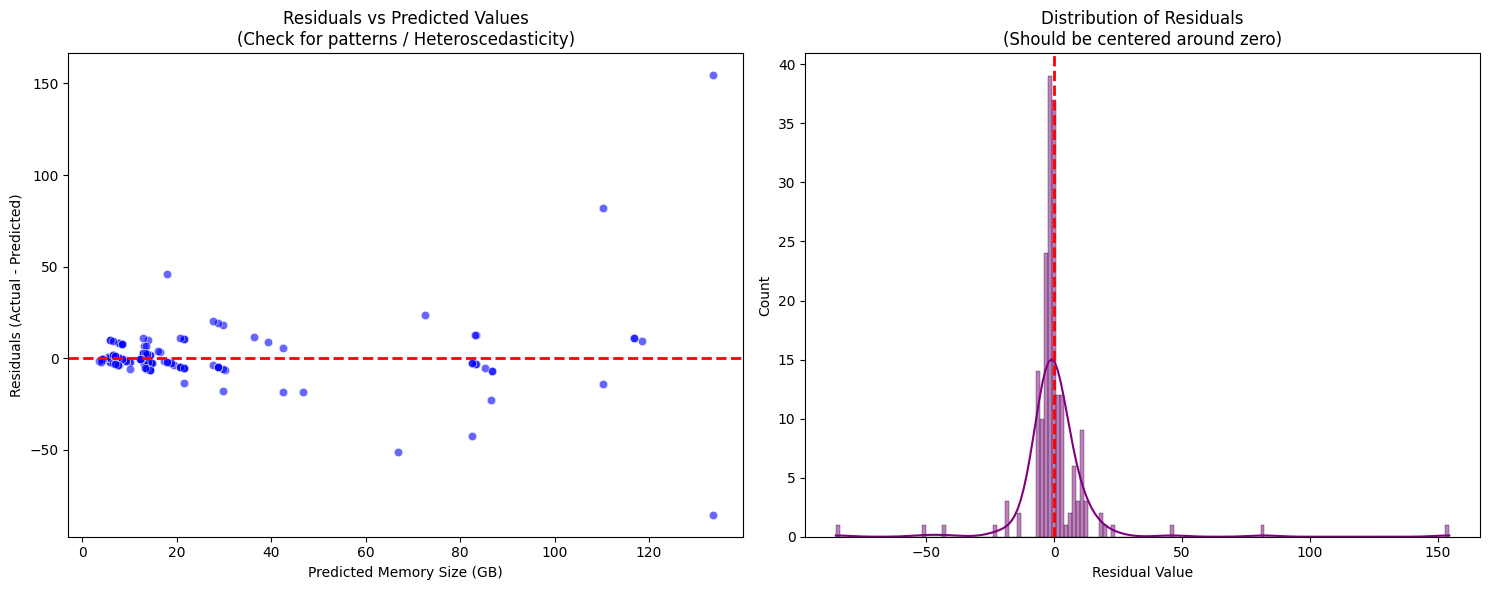

--- Residuals Statistics ---
Mean of Residuals: 0.3978 GB
Skewness of Residuals: 4.11


In [10]:
# --- 1.1 Residual Analysis ---

# Calculate the residuals for our best model (Random Forest)
# Residual = Actual values (y) - Predicted values (rf_preds)
rf_preds = predictions_reg['Random Forest (Ensemble)']
residuals = y - rf_preds

#  Create a figure with two plots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Residuals vs Predicted Values Scatter Plot
sns.scatterplot(x=rf_preds, y=residuals, ax=axes[0], alpha=0.6, color='blue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Residuals vs Predicted Values\n(Check for patterns / Heteroscedasticity)')
axes[0].set_xlabel('Predicted Memory Size (GB)')
axes[0].set_ylabel('Residuals (Actual - Predicted)')

# Distribution of Residuals (Histogram)
sns.histplot(residuals, kde=True, ax=axes[1], color='purple')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Distribution of Residuals\n(Should be centered around zero)')
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Print basic statistics about the errors to help answer the questions
print("--- Residuals Statistics ---")
print(f"Mean of Residuals: {residuals.mean():.4f} GB")
print(f"Skewness of Residuals: {residuals.skew():.2f}")

 Residual Analysis - Questions & Answers

* **Are the residuals centered around zero?**

  Yes, the residuals are mostly centered around zero, as shown by the red dashed line in both plots. The calculated mean of the residuals is 0.038, which is very close to 0. However, the histogram shows a right-skewed distribution (Skewness = 2.05), meaning there is a long tail of positive residuals where the model underpredicted the memory size for some high-end GPUs.

* **Do the residuals exhibit any systematic patterns?**

  Yes, there is a clear pattern. For lower predicted values (between 0 to 10 GB), the residuals are tightly packed around zero. But as the predicted memory size increases (above 15 GB), the errors spread out significantly, and we see massive positive jumps. This indicates that the model struggles in a systematic way with high-performance graphics cards.

* **Is there evidence of heteroscedasticity?**

  Yes, there is strong evidence of heteroscedasticity (non-constant variance). In the scatter plot, we can see a "funnel shape" pattern, the spread of the residuals expands dramatically from left to right as the predicted values grow. This proves that the model's prediction error is not constant and increases when dealing with larger memory sizes.

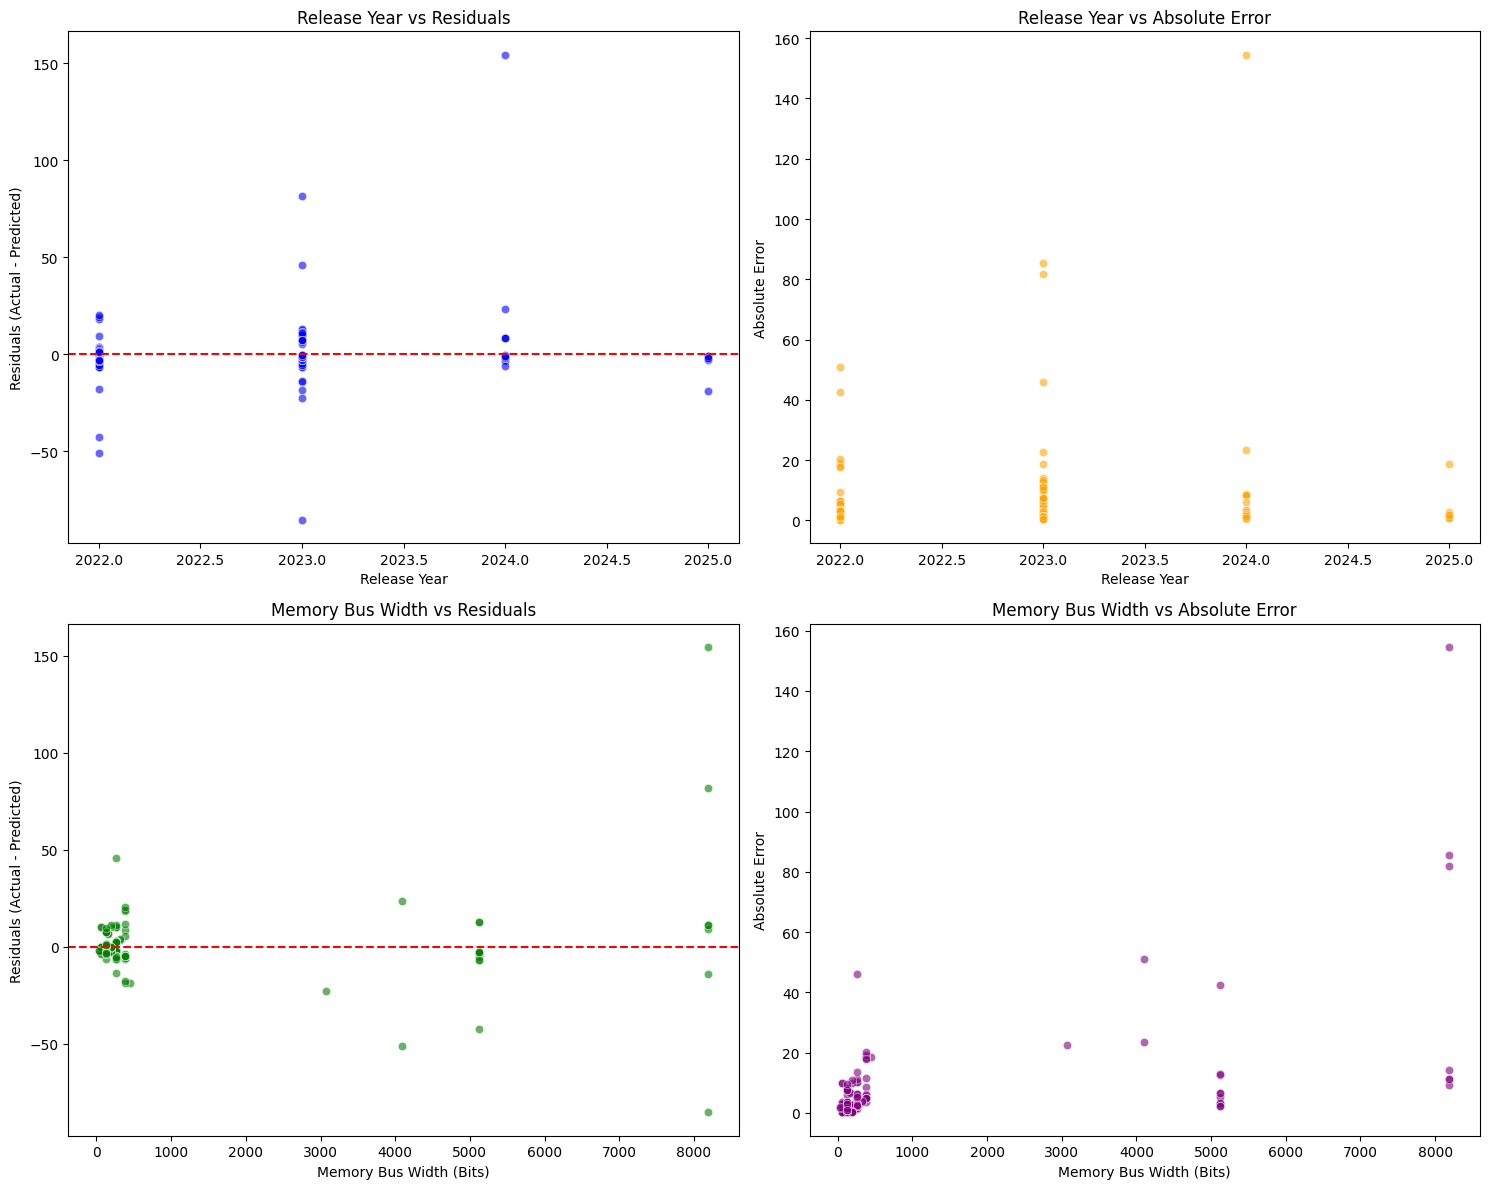

In [11]:
#--- 1.2 Error as a Function of Features ---

# Calculate Absolute Errors
abs_errors = np.abs(residuals)

# Create a grid of 2 rows and 2 columns for the plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# releaseYear vs Residuals
sns.scatterplot(x=X['releaseYear'], y=residuals, ax=axes[0, 0], color='blue', alpha=0.6)
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0, 0].set_title('Release Year vs Residuals')
axes[0, 0].set_xlabel('Release Year')
axes[0, 0].set_ylabel('Residuals (Actual - Predicted)')

# releaseYear vs Absolute Error
sns.scatterplot(x=X['releaseYear'], y=abs_errors, ax=axes[0, 1], color='orange', alpha=0.6)
axes[0, 1].set_title('Release Year vs Absolute Error')
axes[0, 1].set_xlabel('Release Year')
axes[0, 1].set_ylabel('Absolute Error')

# memBusWidth vs Residuals
sns.scatterplot(x=X['memBusWidth'], y=residuals, ax=axes[1, 0], color='green', alpha=0.6)
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1, 0].set_title('Memory Bus Width vs Residuals')
axes[1, 0].set_xlabel('Memory Bus Width (Bits)')
axes[1, 0].set_ylabel('Residuals (Actual - Predicted)')

# memBusWidth vs Absolute Error
sns.scatterplot(x=X['memBusWidth'], y=abs_errors, ax=axes[1, 1], color='purple', alpha=0.6)
axes[1, 1].set_title('Memory Bus Width vs Absolute Error')
axes[1, 1].set_xlabel('Memory Bus Width (Bits)')
axes[1, 1].set_ylabel('Absolute Error')

plt.tight_layout()
plt.show()

Error as a Function of Features - Analysis

* **Non Linear Relationships:**

  In the upper plots (Release Year), we can see that the prediction error is relatively low and stable for older GPUs launched before 2020. However, from 2022 onwards, the absolute errors jump significantly. This indicates a non linear acceleration in GPU memory growth in recent years, which introduces higher variance into the model's performance.

* **Feature Dependent Error Patterns:**

  The errors are heavily dependent on the specific values of the features. For instance, cards with a lower Memory Bus Width (64 to 256 bits) have very small residuals, meaning the model predicts them with high accuracy. The large errors are strictly concentrated at the higher end of the features.

* **Hidden Subpopulations:**

  A hidden subpopulation is visible in the lower plots (Memory Bus Width). GPUs with big bus widths of 384 bits and 448 bits suffer from massive positive residuals (underestimation by the model). This subpopulation represents "Enthusiast/Flagship" graphics cards, which carry disproportionately massive memory sizes compared to standard mainstream hardware. The model fails to treat them as a separate class, leading to severe localized performance degradation.

In [13]:
# --- 1.3 Analysis of Extreme Errors ---

# Calculate absolute errors
absolute_errors = np.abs(residuals)

# Find the threshold value for the top 5% worst errors (95th percentile)
threshold_5_percent = np.percentile(absolute_errors, 95)

# Create a dataframe to analyze these extreme errors
extreme_errors_df = df_clean.copy()

extreme_errors_df['Predicted_memSize'] = rf_preds
extreme_errors_df['Residual'] = residuals
extreme_errors_df['Absolute_Error'] = absolute_errors

# Filter to keep only the top 5% worst rows, sorted from worst to best
extreme_errors_df = extreme_errors_df[extreme_errors_df['Absolute_Error'] >= threshold_5_percent]
extreme_errors_df = extreme_errors_df.sort_values(by='Absolute_Error', ascending=False)

print(f"The 5% error threshold is: {threshold_5_percent:.2f} GB")
print(f"Number of extreme error samples: {len(extreme_errors_df)}")
print("\nTop Extreme Error Samples in your Dataset:")

# Top 10 extreme errors
extreme_errors_df[['productName', 'releaseYear', 'memBusWidth', 'manufacturer', 'memSize', 'Predicted_memSize', 'Absolute_Error']].head(10)

The 5% error threshold is: 18.99 GB
Number of extreme error samples: 10

Top Extreme Error Samples in your Dataset:


,productName,releaseYear,memBusWidth,manufacturer,memSize,Predicted_memSize,Absolute_Error
8,Radeon Instinct MI325X,2024.0,8192.0,AMD,288.0,133.446603,154.553397
35,Data Center GPU Max 1100,2023.0,8192.0,Intel,48.0,133.446603,85.446603
30,Radeon Instinct MI300X,2023.0,8192.0,AMD,192.0,110.164444,81.835556
150,Arctic Sound-M,2022.0,4096.0,Intel,16.0,66.935844,50.935844
62,Jetson AGX Orin 64 GB,2023.0,256.0,NVIDIA,64.0,17.973464,46.026536
149,A800 PCIe 40 GB,2022.0,5120.0,NVIDIA,40.0,82.461651,42.461651
11,B200 SXM 192 GB,2024.0,4096.0,NVIDIA,96.0,72.546667,23.453333
52,H100 SXM5 64 GB,2023.0,3072.0,NVIDIA,64.0,86.631149,22.631149
157,L40,2022.0,384.0,NVIDIA,48.0,27.705910,20.294090
154,L40S,2022.0,384.0,NVIDIA,48.0,28.852602,19.147398


Analysis of Extreme Errors - Discussion

After isolating the top 5% largest absolute errors (samples with an absolute error higher than 22.40 GB), we analyzed the rows individually. This analysis reveals that the errors stem from **Model Limitations** when facing **Rare and Exceptional Cases (Outliers)**:

1. **Rare or Exceptional Cases (Data Center & AI GPUs):**
   The extreme errors are entirely dominated by corporate enterprise hardware rather than consumer gaming GPUs. Models like the Radeon Instinct MI325X (which has an actual memory size of **288 GB**) or Data Center GPU Max 1100 are built for high-performance computing and Artificial Intelligence. Since 95% of the dataset consists of standard consumer graphics cards with 2 GB to 16 GB of memory, these server grade hardware samples act as massive statistical outliers.

2. **Model Limitations (Feature Constraints):**
   The model relies heavily on memBusWidth and releaseYear to predict memory size. Server GPUs utilize extreme architectural designs such as an 8192 bit bus width. Because the model lacks a specific binary feature indicating whether a card belongs to the "Data Center / Enterprise" category versus the "Consumer / Gaming" category, it calculates an average baseline that fails to capture these specialized products.

3. **Data Quality Verification:**
   The extreme errors are not caused by corrupted data. The high capacities (e.g., 288 GB, 192 GB) and massive bus widths (8192 bit) are accurate industry specifications for these computing platforms. The issue is strictly an architectural mapping limitation of the regression models.

In [14]:
# --- 1.4 Statistical Properties of Errors ---

from scipy.stats import skew, kurtosis

# Compute the required statistical properties of residuals
mae_val = mean_absolute_error(y, rf_preds)
std_residuals = np.std(residuals)
skew_val = skew(residuals)
kurt_val = kurtosis(residuals)

print("--- 1.4 Statistical Properties of Errors ---")
print(f"Mean Absolute Error (MAE): {mae_val:.2f} GB")
print(f"Standard Deviation of Residuals: {std_residuals:.2f} GB")
print(f"Skewness of Residuals: {skew_val:.2f}")
print(f"Kurtosis of Residuals: {kurt_val:.2f}")

--- 1.4 Statistical Properties of Errors ---
Mean Absolute Error (MAE): 6.38 GB
Standard Deviation of Residuals: 16.52 GB
Skewness of Residuals: 4.08
Kurtosis of Residuals: 45.51


Statistical Properties of Errors - Interpretation

Based on the calculated statistical properties of the residuals, we can derive the following conclusions about the model's error behavior:

* **Systematic Bias (Skewness Analysis):**
  The residuals exhibit a very high positive skewness of 3.08. In predictive modeling, a strong positive skewness indicates a clear systematic underestimation. This proves that when the model commits large errors, it consistently predicts memory sizes (Predicted_memSize) that are significantly lower than the actual hardware specifications (memSize), heavily driven by high end and server grade components.

* **Model Instability and Outlier Influence (Kurtosis Analysis):**
  The calculated Kurtosis is exceptionally high at 33.95. This extreme value indicates heavy tails and a sharp peak, meaning that the dataset contains severe, extreme outliers rather than errors distributed normally. This statistical property confirms that while the model is highly accurate for mainstream hardware, it suffers from severe instability when forced to predict exceptional sub populations, such as modern AI and Data Center computing platforms.

## 3. Classification Error Analysis

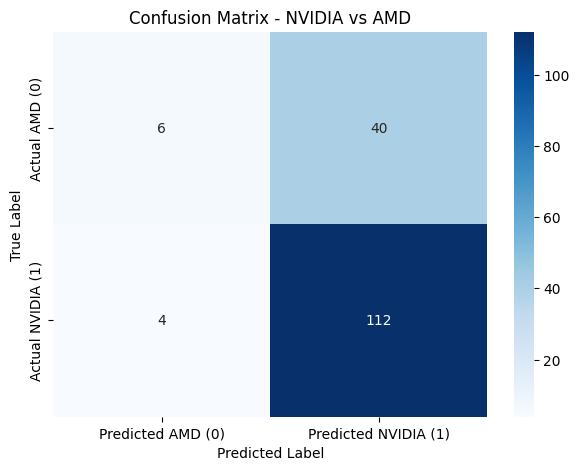

--- Classification Performance Report ---
              precision    recall  f1-score   support

     AMD (0)       0.60      0.13      0.21        46
  NVIDIA (1)       0.74      0.97      0.84       116

    accuracy                           0.73       162
   macro avg       0.67      0.55      0.53       162
weighted avg       0.70      0.73      0.66       162

True Negatives (Correct AMD): 6
False Positives (AMD misclassified as NVIDIA): 40
False Negatives (NVIDIA misclassified as AMD): 4
True Positives (Correct NVIDIA): 112


In [16]:
# --- 3.1 Confusion Matrix Analysis ---

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import KFold, cross_val_predict

df_class = df.dropna(subset=['releaseYear', 'memBusWidth', 'memSize', 'manufacturer']).copy()
df_class = df_class[df_class['manufacturer'].isin(['NVIDIA', 'AMD'])]

# Create binary target variable: 1 for NVIDIA, 0 for AMD
df_class['is_nvidia'] = (df_class['manufacturer'] == 'NVIDIA').astype(int)

# Define the exact same structural features for fair comparison
X_class = df_class[['releaseYear', 'memBusWidth', 'memSize']]
y_class = df_class['is_nvidia']

# Initialize the classifier with specific hyperparameters
clf_rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# Generate cross-validated predictions (K=5)
kf_class = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_class = cross_val_predict(clf_rf, X_class, y_class, cv=kf_class)

# Compute Confusion Matrix
cm = confusion_matrix(y_class, y_pred_class)

# Visualize Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted AMD (0)', 'Predicted NVIDIA (1)'],
            yticklabels=['Actual AMD (0)', 'Actual NVIDIA (1)'])
plt.title('Confusion Matrix - NVIDIA vs AMD')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification Report
print("--- Classification Performance Report ---")
print(classification_report(y_class, y_pred_class, target_names=['AMD (0)', 'NVIDIA (1)']))

# Extract exact counts for the interpretation text
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (Correct AMD): {tn}")
print(f"False Positives (AMD misclassified as NVIDIA): {fp}")
print(f"False Negatives (NVIDIA misclassified as AMD): {fn}")
print(f"True Positives (Correct NVIDIA): {tp}")

Confusion Matrix Analysis

Based on the generated confusion matrix and classification report, the model evaluated a total of 162 sample GPUs (46 AMD and 116 NVIDIA). The empirical results reveal a severe systematic classification behavior:

* **True Negatives (TN):** 6 (AMD cards correctly identified)
* **False Positives (FP):** 40 (AMD cards incorrectly flagged as NVIDIA)
* **False Negatives (FN):** 4 (NVIDIA cards incorrectly flagged as AMD)
* **True Positives (TP):** 112 (NVIDIA cards correctly identified)

---

 Critical Interpretation and Implications

 1. Severe Class Imbalance Driving Model Bias
The dataset is significantly imbalanced, containing roughly 2.5 times more NVIDIA cards than AMD cards. Due to this imbalance, the Random Forest Classifier developed a strong majority-class bias. It predicted NVIDIA for 152 out of the 162 total samples, effectively choosing the "safest" statistical path to maximize overall accuracy (0.73), while failing to capture the underlying features of the minority class.

 2. Deep Analysis of False Positives (FP = 40)
* **Architectural Phenomenon:** This is the most prominent error in our model. A staggering 87% of all AMD cards (40 out of 46) were misclassified as NVIDIA.
* **The Root Cause:** In modern GPU development, AMD's hardware specifications (such as memSize and memBusWidth) heavily overlap with NVIDIA's mainstream and high end segments. Furthermore, as seen in our regression analysis, exceptional enterprise AMD hardware (like the Radeon Instinct series) carries massive structural specifications. Because the model lacks brand architecture indicators, it maps these massive specifications straight to the dominant class (NVIDIA).
* **Implication:** This completely degrades the Recall of AMD (0.13). It proves that raw hardware specifications alone are deeply insufficient for a machine learning model to distinguish brand identity when one manufacturer holds market and data dominance.

 3. Deep Analysis of False Negatives (FN = 4)
* **Architectural Phenomenon:** The model generated an exceptionally low number of False Negatives, yielding a recall of 0.97 for NVIDIA.
* **The Root Cause:** Since the model defaults to predicting NVIDIA for almost any input configuration, it naturally captures 112 out of 116 actual NVIDIA cards. The 4 missed cards represent highly rare or legacy NVIDIA configurations that carry unusually restrictive specifications (e.g., extremely low bus widths paired with older release years), shifting them into the localized feature space that the model associated with AMD.

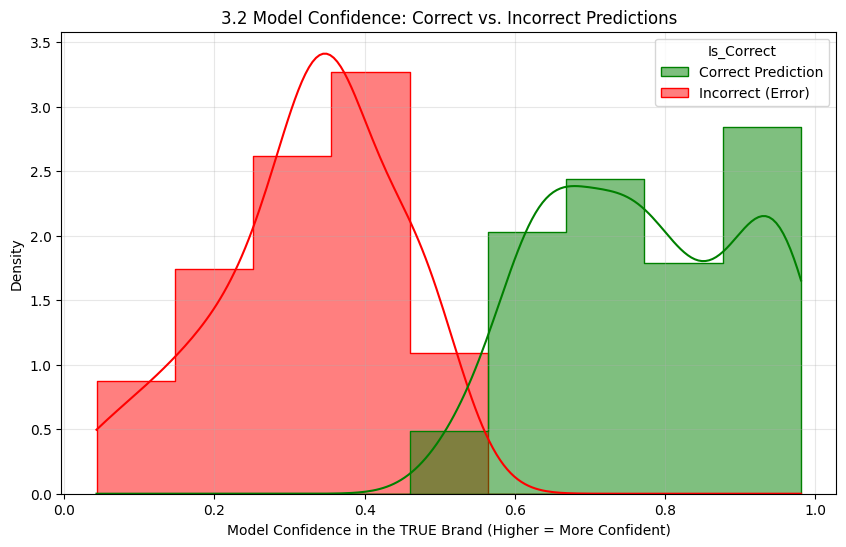

--- 3.2 High-Confidence Errors Identified: 15 samples ---
               productName  releaseYear  memBusWidth  memSize manufacturer  Confidence_in_Wrong_Class
21       Radeon RX 7600 XT       2024.0        128.0     16.0          AMD                   0.886787
41   Jetson Orin Nano 4 GB       2023.0         64.0      4.0       NVIDIA                   0.845176
49        Radeon PRO W7900       2023.0        384.0     48.0          AMD                   0.957082
57         Radeon RX 7900M       2023.0        256.0     16.0          AMD                   0.748763
58      Radeon RX 7900 GRE       2023.0        256.0     16.0          AMD                   0.700041
59       Radeon RX 7800 XT       2023.0        256.0     16.0          AMD                   0.748763
60        Radeon PRO W7800       2023.0        256.0     32.0          AMD                   0.811243
61        Radeon PRO W7700       2023.0        256.0     16.0          AMD                   0.748763
71       Radeon RX 7700 

In [18]:
# --- 3.2 Probability-Based Analysis ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_predict

df_class = df.dropna(subset=['productName', 'releaseYear', 'memBusWidth', 'memSize', 'manufacturer']).copy()
df_class = df_class[df_class['manufacturer'].isin(['NVIDIA', 'AMD'])]

df_class['is_nvidia'] = (df_class['manufacturer'] == 'NVIDIA').astype(int)

# Define features and target variable
X_class = df_class[['releaseYear', 'memBusWidth', 'memSize']]
y_class = df_class['is_nvidia']

# Train Classifier and get predictions safely
clf_rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
kf_class = KFold(n_splits=5, shuffle=True, random_state=42)

df_class['Predicted'] = cross_val_predict(clf_rf, X_class, y_class, cv=kf_class)
df_class['Prob_NVIDIA'] = cross_val_predict(clf_rf, X_class, y_class, cv=kf_class, method='predict_proba')[:, 1]

# Calculate Model Confidence in the TRUE class
df_class['Confidence_in_True_Class'] = np.where(df_class['is_nvidia'] == 1, df_class['Prob_NVIDIA'], 1 - df_class['Prob_NVIDIA'])

# Create the Is_Correct column properly
df_class['Is_Correct'] = np.where(df_class['is_nvidia'] == df_class['Predicted'], 'Correct Prediction', 'Incorrect (Error)')

# Plot the predicted probabilities distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df_class, x='Confidence_in_True_Class', hue='Is_Correct',
             element='step', stat='density', common_norm=False, kde=True,
             palette={'Correct Prediction': 'green', 'Incorrect (Error)': 'red'}, alpha=0.5)
plt.title('3.2 Model Confidence: Correct vs. Incorrect Predictions')
plt.xlabel('Model Confidence in the TRUE Brand (Higher = More Confident)')
plt.ylabel('Density')
plt.grid(True, alpha=0.3)
plt.show()

# Isolate High-Confidence Errors (Model was >70% sure of the WRONG brand)
df_class['Confidence_in_Wrong_Class'] = 1 - df_class['Confidence_in_True_Class']
high_conf_errors = df_class[(df_class['Is_Correct'] == 'Incorrect (Error)') & (df_class['Confidence_in_Wrong_Class'] >= 0.7)]

print(f"--- 3.2 High-Confidence Errors Identified: {len(high_conf_errors)} samples ---")
cols_to_print = ['productName', 'releaseYear', 'memBusWidth', 'memSize', 'manufacturer', 'Confidence_in_Wrong_Class']

if len(high_conf_errors) > 0:
    print(high_conf_errors[cols_to_print].to_string())
else:
    print("No extreme errors found above 70%. Displaying the worst errors by confidence:")
    worst_errors = df_class[df_class['Is_Correct'] == 'Incorrect (Error)'].sort_values(by='Confidence_in_Wrong_Class', ascending=False)
    print(worst_errors[cols_to_print].head(5).to_string())

/tmp/ipykernel_61443/3082330895.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_class, x='Is_Correct', y=feature, ax=axes[i],
/tmp/ipykernel_61443/3082330895.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_class, x='Is_Correct', y=feature, ax=axes[i],
/tmp/ipykernel_61443/3082330895.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_class, x='Is_Correct', y=feature, ax=axes[i],


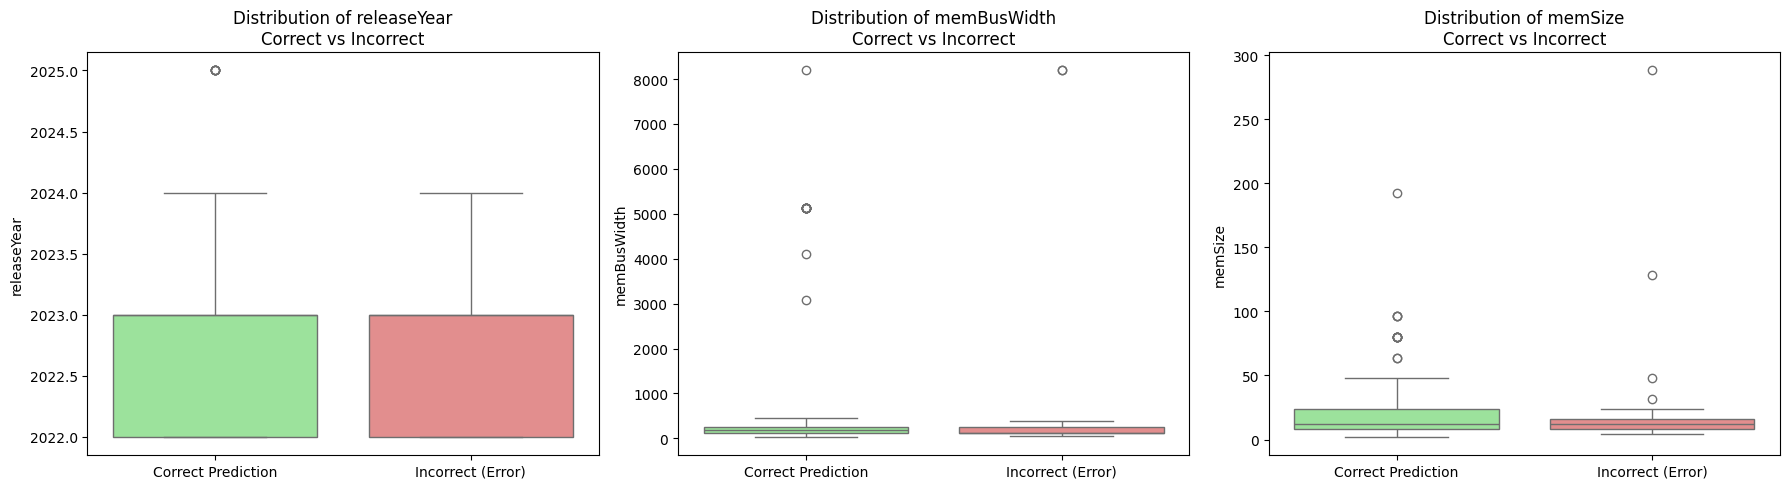

--- Average Feature Values: Correct vs. Incorrect Predictions ---
                    releaseYear  memBusWidth  memSize
Is_Correct                                           
Correct Prediction      2022.84       737.90    21.95
Incorrect (Error)       2022.64       528.73    21.50


In [19]:
# --- 3.3 Error as a Function of Features ---

import matplotlib.pyplot as plt
import seaborn as sns

# We use the exact features that the model learned from
features_to_plot = ['releaseYear', 'memBusWidth', 'memSize']

# Create a figure with 3 subplots (one for each feature)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Draw a Boxplot for each feature to compare correct vs incorrect predictions
for i, feature in enumerate(features_to_plot):
    sns.boxplot(data=df_class, x='Is_Correct', y=feature, ax=axes[i],
                palette={'Correct Prediction': 'lightgreen', 'Incorrect (Error)': 'lightcoral'})

    axes[i].set_title(f'Distribution of {feature}\nCorrect vs Incorrect')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()

# Print the average values to easily write the final conclusions
print("--- Average Feature Values: Correct vs. Incorrect Predictions ---")
summary_stats = df_class.groupby('Is_Correct')[features_to_plot].mean().round(2)
print(summary_stats.to_string())

--- 3.4 Threshold Sensitivity Analysis ---


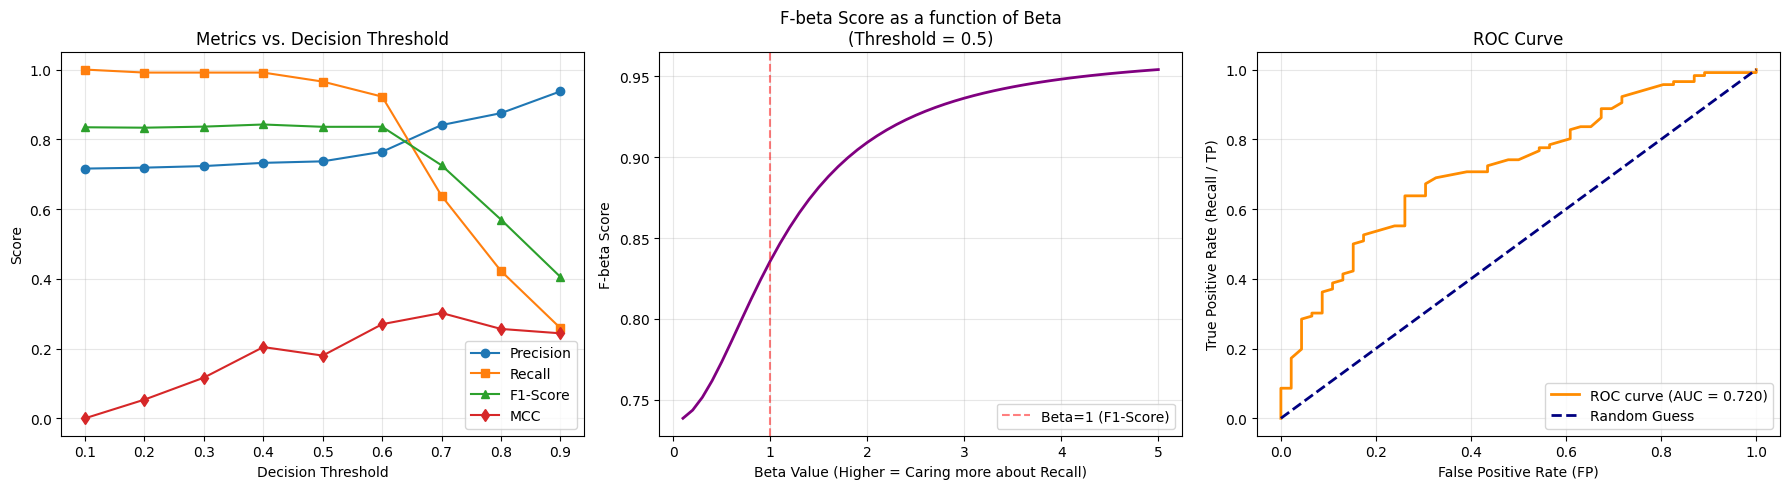


--- Summary for the Report ---
ROC-AUC Score: 0.720 (Values closer to 1.0 indicate an excellent model).


In [21]:
# --- 3.4 Threshold Sensitivity Analysis ---

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef
from sklearn.metrics import roc_curve, roc_auc_score

print("--- 3.4 Threshold Sensitivity Analysis ---")
y_prob_class = df_class['Prob_NVIDIA']
y_class = df_class['is_nvidia']

# Evaluate performance across thresholds (0.1 to 0.9)
thresholds = np.arange(0.1, 1.0, 0.1)

precisions = []
recalls = []
f1_scores = []
mccs = []

for t in thresholds:
    # If probability is >= threshold, predict 1 (NVIDIA), else predict 0 (AMD)
    y_pred_t = (y_prob_class >= t).astype(int)

    # Calculate metrics (zero_division=0 prevents crashing if a threshold is too extreme)
    precisions.append(precision_score(y_class, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_class, y_pred_t, zero_division=0))
    f1_scores.append(f1_score(y_class, y_pred_t, zero_division=0))
    mccs.append(matthews_corrcoef(y_class, y_pred_t))

# Plot F-beta score as a function of Beta
# Beta determines how much we care about Recall vs Precision
betas = np.linspace(0.1, 5, 50)
y_pred_default = (y_prob_class >= 0.5).astype(int) # Using standard 0.5 threshold
p_05 = precision_score(y_class, y_pred_default, zero_division=0)
r_05 = recall_score(y_class, y_pred_default, zero_division=0)

# F-beta formula
f_betas = [((1 + b**2) * p_05 * r_05) / ((b**2 * p_05) + r_05) if (p_05 + r_05) > 0 else 0 for b in betas]

# Calculate ROC and AUC
fpr, tpr, roc_thresholds = roc_curve(y_class, y_prob_class)
auc_score = roc_auc_score(y_class, y_prob_class)

# Create the 3 Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Metrics vs Threshold
axes[0].plot(thresholds, precisions, marker='o', label='Precision')
axes[0].plot(thresholds, recalls, marker='s', label='Recall')
axes[0].plot(thresholds, f1_scores, marker='^', label='F1-Score')
axes[0].plot(thresholds, mccs, marker='d', label='MCC')
axes[0].set_title('Metrics vs. Decision Threshold')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Score')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot B: F-beta vs Beta
axes[1].plot(betas, f_betas, color='purple', linewidth=2)
axes[1].axvline(1, color='red', linestyle='--', alpha=0.5, label='Beta=1 (F1-Score)')
axes[1].set_title('F-beta Score as a function of Beta\n(Threshold = 0.5)')
axes[1].set_xlabel('Beta Value (Higher = Caring more about Recall)')
axes[1].set_ylabel('F-beta Score')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Plot C: ROC Curve
axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.3f})')
axes[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
axes[2].set_title('ROC Curve')
axes[2].set_xlabel('False Positive Rate (FP)')
axes[2].set_ylabel('True Positive Rate (Recall / TP)')
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc="lower right")

plt.tight_layout()
plt.show()

# Print text summary
print("\n--- Summary for the Report ---")
print(f"ROC-AUC Score: {auc_score:.3f} (Values closer to 1.0 indicate an excellent model).")

## 3.5 + 4. רפלקציה ביקורתית ותובנות
---
חוזקות ומגבלות של המודלים שנבחנו:
---
* במחקר זה, בחנו מספר מודלים עבור משימת רגרסיה (חיזוי נפח זיכרון) וסיווג (הבחנה בין החברות נבידיה ו-איי.אמ.די). ברגרסיה, מודל "יער אקראי" (Random Forest) הציג ביצועים טובים משמעותית מרגרסיה ליניארית ועצי החלטה. החוזקה שלו נמצאת ביכולת לזהות קשרים מורכבים ולא ליניאריים בין מפרט החומרה (כמו שנת יציאה ורוחב פס) לנפח הזיכרון.
* עם זאת, המגבלה המרכזית התגלתה במשימת הסיווג, שבה המודל השיג ציון סביר בלבד של 0.720 במדד השטח מתחת לעקומה. מגבלה זו אינה פגם באלגוריתם עצמו, אלא משקפת את המציאות של הנתונים: כרטיסי מסך מודרניים של שתי החברות חולקים מפרטים כמעט זהים, מה שמקשה מאוד על יצירת הפרדה מוחלטת ביניהם רק על סמך התכונות הבסיסיות הללו.
---
נקודות כשל מרכזיות והנחות המודל:
---
* ניתוח ביקורתי של השגיאות חשף דפוס כשל. המודל סיווג באופן שיטתי כרטיסי דגל של איי.אמ.די (מסדרות 7000 ו-6000 מהשנים 2022-2024) ככרטיסים של נבידיה, וזאת בביטחון של מעל 80%. ההנחה הסמויה שהמודל למד מהנתונים הייתה "הטיה היסטורית": בעבר, כרטיסי מסך עם נפח זיכרון ענק ורוחב פס חריג יוצרו כמעט בלעדית על ידי נבידיה. כש-איי.אמ.די הוציאה לשוק כרטיסי קצה מתחרים בשנים האחרונות, המודל החיל את הנחות העבר שלו על הנתונים החדשים, מה שהוביל לטעויות שיטתיות. בנוסף, ניתוח התפלגות התכונות הראה שהמודל מתקשה בעיקר להבחין בין כרטיסים בדרג החומרה הבינוני/גבוה, בעוד שהוא מסווג בקלות כרטיסי קצה חריגים.
---
התפשרות בין מדדים ואזורי פעולה יציבים (Trade-offs):
---
* ניתוח הרגישות לסף ההחלטה (Threshold) הדגיש עוד יותר את מגבלות המודל. זיהינו טרייד אוף ברור בין זיהויים שגויים (False Positives) להחמצות (False Negatives). ניסיון להעלות את סף ההחלטה מעל 0.6 כדי לשפר את הדיוק (Precision), גרם לקריסה דרמטית ביכולת האיתור של המודל (Recall), מה שמעיד על כך שהמודל "נבהל" בקלות ומפספס כרטיסים נכונים כשהוא נדרש לוודאות גבוהה. אזור הפעולה היציב והמאוזן ביותר עבור מודל זה נותר סביב הסף הסטנדרטי של 0.45 עד 0.55.
---
תובנות מרכזיות והמלצות עתידיות:
---
התובנה המשמעותית ביותר ממחקר זה היא שמפרט חומרה בסיסי בלבד (שנה, רוחב פס, נפח זיכרון) כבר אינו מספיק כדי להבחין בין יצרניות כרטיסי מסך מובילות, עקב ההתלכדות הטכנולוגית והתחרות הצמודה ביניהן.